<a href="https://colab.research.google.com/github/hehahahahehe/SimpleRLfin/blob/main/SimpleRLtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Set packages, may report error. Run the block following to check if it set successful.

```
# 此内容为代码格式
```



In [1]:
# 1. 安装系统依赖
!apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig

# 2. 安装 FinRL 和关键补丁包
!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git
!pip install gymnasium stable-baselines3 shimmy[gym-anygh] yfinance stockstats

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package javascript-common.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../0-javascript-common_11+nmu1_all.deb ...
Unpacking javascript-common (11+nmu1) ...
Selecting previously unselected package libjs-underscore.
Preparing to unpack .../1-libjs-underscore_1.13.2~dfsg-2_all.deb ...
Unpacking libjs-underscore (1.13.2~dfsg-2) ...
Selecting previously unselected package libjs-sphinxdoc.
Preparing to unpack .../2-libjs-sphinxdoc_4.3.2-1_all.deb ...
Unpacking libjs-sphinxdoc (4.3.2-1) ...
Selecting previously unselected package python3.10-dev.
Preparing to unpack .../3-python3.10-dev_3.10.12-1~22.04.13_amd64.deb ...
Unpacking python3.10-dev (3.10.12-1~22.04.13) ...
Selecting previously unselected package python3-dev.
Prepari

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
^C


Test block, run it to check finrl installed or not

In [1]:
import finrl


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


AttributeError: module 'finrl' has no attribute '__version__'

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Train ppo here. Modefy asserts by change TICKETS

In [6]:
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline
import datetime

# 1. 配置参数：我们选几只 2025-2026 年表现强劲的 AI 概念股
TICKERS = ['NVDA', 'AAPL', 'MSFT', 'GOOGL', 'AMZN']
TRAIN_START = '2023-01-01'
TRAIN_END = '2025-06-01'
TRADE_START = '2025-06-01'
TRADE_END = '2026-01-25' # 接近当前时间

# 2. 下载并处理数据
df = YahooDownloader(start_date=TRAIN_START, end_date=TRADE_END, ticker_list=TICKERS).fetch_data()
fe = FeatureEngineer(use_technical_indicator=True, user_defined_feature=False)
processed = fe.preprocess_data(df)

# 3. 划分训练集和交易集
train = data_split(processed, TRAIN_START, TRAIN_END)
trade = data_split(processed, TRADE_START, TRADE_END)

# 4. 构建环境
# 动态计算维度，防止硬编码错误
num_stocks = len(train.tic.unique())
num_indicators = len(env_kwargs['tech_indicator_list'])

# FinRL 标准状态空间公式：
# [balance] + [prices] + [shares] + [indicators]
# 1 + num_stocks + num_stocks + (num_indicators * num_stocks)
new_state_space = 1 + 2 * num_stocks + num_indicators * num_stocks

env_kwargs["state_space"] = new_state_space
env_kwargs["stock_dim"] = num_stocks
env_kwargs["num_stock_shares"] = [0] * num_stocks
env_kwargs["buy_cost_pct"] = [0.001] * num_stocks
env_kwargs["sell_cost_pct"] = [0.001] * num_stocks

print(f"修正后的状态空间维度: {new_state_space}")

e_train_gym = StockTradingEnv(df=train, **env_kwargs)

# 5. 训练 PPO 智能体
agent = DRLAgent(env=e_train_gym)
model_ppo = agent.get_model("ppo")
trained_ppo = agent.train_model(model=model_ppo, tb_log_name='ppo', total_timesteps=30000)

# 6. 开始回测
e_trade_gym = StockTradingEnv(df=trade, turbulence_threshold=None, **env_kwargs)
df_account_value, df_actions = DRLAgent.DRL_prediction(model=trained_ppo, environment=e_trade_gym)

# 7. 输出表现指标
print("============== 回测统计结果 ==============")
perf_stats_all = backtest_stats(account_value=df_account_value)

[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

[*********************100%***********************]  1 of 1 completed/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for re

Shape of DataFrame:  (3835, 8)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Successfully added technical indicators
修正后的状态空间维度: 31
{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 64}
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


day: 603, episode: 50
begin_total_asset: 100000.00
end_total_asset: 208219.20
total_reward: 108219.20
total_cost: 17539.08
total_trades: 2658
Sharpe: 1.103


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 604          |
|    ep_rew_mean          | 13.9         |
| time/                   |              |
|    fps                  | 370          |
|    iterations           | 15           |
|    time_elapsed         | 83           |
|    total_timesteps      | 30720        |
| train/                  |              |
|    approx_kl            | 0.0076089418 |
|    clip_fraction        | 0.0645       |
|    clip_range           | 0.2          |
|    entropy_loss         | -7.12        |
|    explained_variance   | 0.191        |
|    learning_rate        | 0.00025      |
|    loss                 | 0.73         |
|    n_updates            | 140          |
|    policy_gradient_loss | -0.00868     |
|    reward               | 0.11614789   |
|    reward_max           | 4.042508     |
|    reward_mean          | 0.030838117  |
|    reward_min           | -4.435956    |
|    std   

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


save model if need

In [10]:

trained_ppo.save("ppo_stock_strategy_2026")

Plot

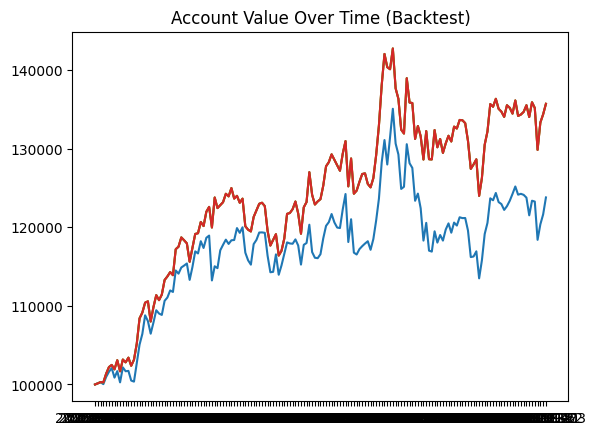

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


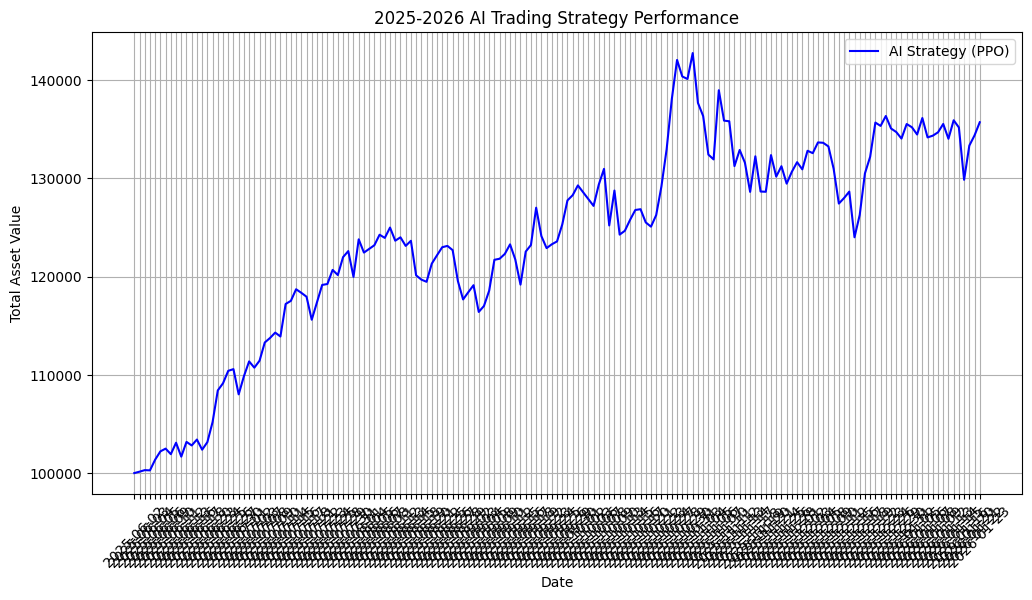

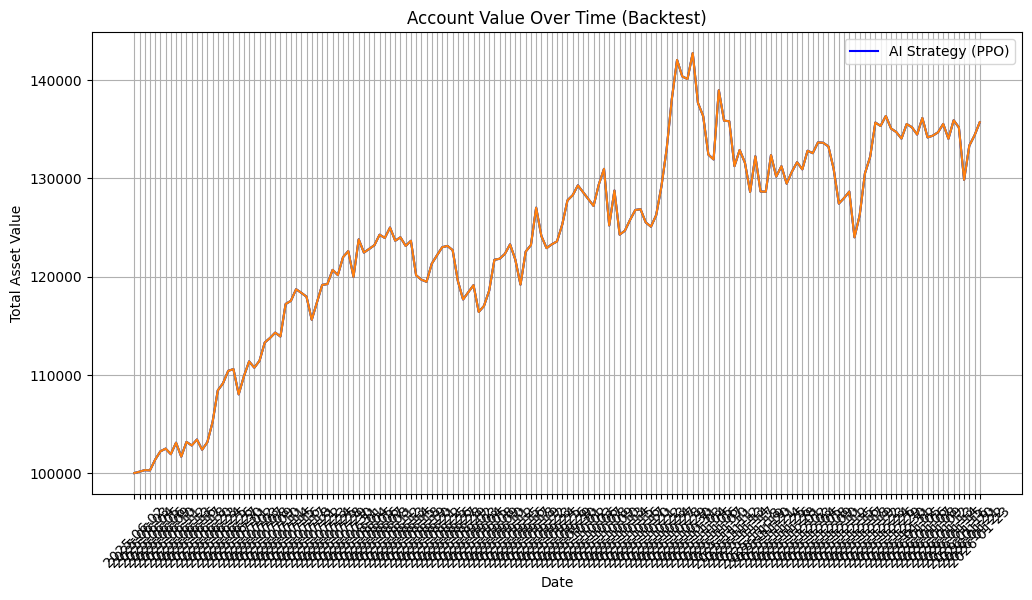

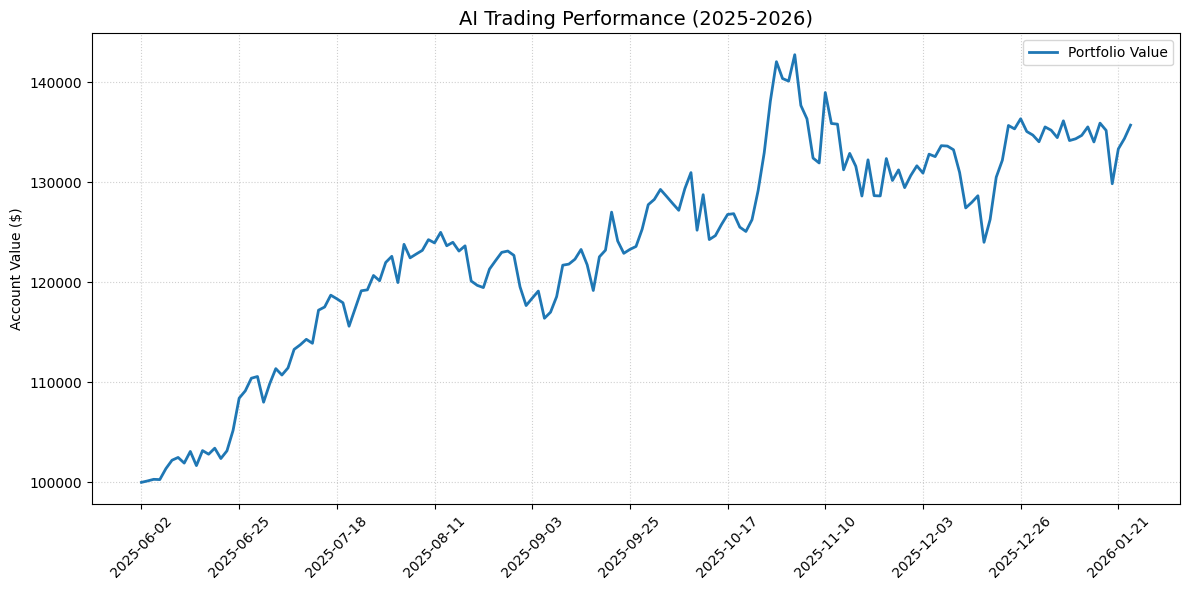

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 创建画布
plt.figure(figsize=(12, 6))

# 2. 核心：用 Range（数字序列）代替日期绘图，彻底避开 tz 报错
values = df_account_value['account_value'].values
plt.plot(np.arange(len(values)), values, color='#1f77b4', linewidth=2, label='Portfolio Value')

# 3. 动态设置 X 轴标签（每隔 30 天显示一个日期）
step = max(1, len(df_account_value) // 10) # 自动计算步长，避免日期太挤
plt.xticks(
    np.arange(0, len(df_account_value), step),
    df_account_value['date'].iloc[::step].astype(str),
    rotation=45
)

# 4. 修饰
plt.title("AI Trading Performance (2025-2026)", fontsize=14)
plt.ylabel("Account Value ($)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()

# 5. 显示
plt.show()

In [ ]:
# --- 1. 使用 Colab 钥匙扣 (Secrets) 安全获取 Token ---
from google.colab import userdata
try:
    token = userdata.get('GITHUB_TOKEN') # 在左侧“钥匙”图标里添加一个名为 GITHUB_TOKEN 的变量
except:
    token = "你的手动Token"

# --- 2. 变量定义 ---
repo_url = "FinRL_Trading_2026"
username = "你的用户名"

# --- 3. 执行 Git 操作 ---
!git config --global user.email "you@example.com"
!git config --global user.name "{username}"

# 如果文件夹还没克隆，先克隆
import os
if not os.path.exists(f'/content/{repo_url}'):
    !git clone https://{token}@github.com/{username}/{repo_url}.git

# 将生成的结果（模型、图表）拷贝进仓库文件夹
!cp ppo_model.zip {repo_url}/
!cp backtest_result.png {repo_url}/

# 推送
%cd {repo_url}
!git add .
!git commit -m "🚀 自动同步: 2026年回测数据更新"
!git push origin main
%cd /content